## 0. Setup — Install Dependencies (Google Colab)

Chạy cell này **1 lần** khi mở notebook trên Colab. Sau đó restart runtime nếu cần.

# ARK (Adaptive Retriever of Knowledge) - End-to-End Demo

Notebook này demo toàn bộ pipeline ARK với **4 model options**:
- 🔹 **Qwen3-4B** — Fine-tuned trên Oracle trajectories (LoRA merged, INT4 quantized)
- 🔹 **Qwen3-0.6B** — Distilled từ Gemini trajectories (LoRA adapter, INT4 quantized)
- 🔹 **Gemini 3.6 Flash** — API-based via Anthropic proxy server (không cần GPU)
- 🔹 **OpenAI (GPT-4o / GPT-4o-mini)** — API-based via OpenAI (không cần GPU)

Pipeline:
1. **Setup & Install** - Cài đặt dependencies
2. **Model Selection** - Chọn 1 trong 4 models
3. **Neo4j Connection** - Kết nối Knowledge Graph
4. **Indexing** - Trích xuất entities/relationships từ text và lưu vào Neo4j
5. **ARK Tools** - Test từng tool riêng lẻ
6. **ARK Agent** - LangGraph state machine
7. **ARK Retriever** - Multi-agent retrieval với Voting Rank Fusion
8. **Evaluation** - So sánh kết quả

In [27]:
# # GPU dependencies (Qwen3 INT4 quantization)
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
# !pip install transformers accelerate bitsandbytes peft

# # LangChain & LangGraph
# !pip install langchain-core langgraph langchain-neo4j "neo4j>=5.15.0" pydantic

# # LangChain model integrations
# !pip install langchain-huggingface langchain-anthropic langchain-openai

# # Utilities
# !pip install nest-asyncio rank-bm25

In [28]:
import os
import re
import json
import asyncio
from typing import Any, Annotated, Dict, List, Optional, Sequence, Type, TypedDict

# Fix HF cache permissions (root-owned cache at ~/.cache/huggingface)
os.environ["HF_HOME"] = "/tmp/hf_cache"

import nest_asyncio
nest_asyncio.apply()

---
## 1. Configuration & Model Selection

Chọn **1 trong 4 models** bằng cách set `MODEL_CHOICE`:
- `"qwen3-4b"` — Qwen3-4B fine-tuned (cần GPU, ~3.5GB VRAM)
- `"qwen3-0.6b"` — Qwen3-0.6B distilled từ Gemini (cần GPU, ~1.2GB VRAM)
- `"gemini"` — Gemini 3.6 Flash qua Anthropic proxy (không cần GPU, cần chạy proxy server)
- `"openai"` — OpenAI GPT-4o / GPT-4o-mini (không cần GPU, cần `OPENAI_API_KEY`)

In [29]:
# ===================== CẤU HÌNH =====================

# --- Model Selection ---
# Chọn 1 trong 4: "qwen3-4b", "qwen3-0.6b", "gemini", "openai"
MODEL_CHOICE = "qwen3-0.6b"

# --- Model Paths (cho Qwen options) ---
MODEL_PATHS = {
    "qwen3-4b": "./qwen3_4b_finetuned",     # symlink -> ark/data/finetuning/prime/Qwen3-4B/f4f2/merged/
    "qwen3-0.6b": "./qwen3_0.6b_distilled",  # symlink -> ark/data/finetuning/prime/Qwen3-0.6B/cfc5/
}

# --- Gemini API Config (dùng Anthropic proxy server) ---
GEMINI_PROXY_URL = "http://localhost:8080"
GEMINI_MODEL = "gemini-3.6-flash"

# --- OpenAI API Config ---
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL = "gpt-4o-mini"

# --- Neo4j (Aura) ---
NEO4J_URI = "neo4j+s://7b2e76d5.databases.neo4j.io"
NEO4J_USERNAME = "7b2e76d5"
NEO4J_PASSWORD = "SFgHYn3w8Rws0MkvwqR05HD99Tj6YqFuTf3_K6AabeY"
NEO4J_DATABASE = "7b2e76d5"

# --- ARK ---
ARK_N_AGENTS = 3
ARK_MAX_STEPS = 30
ARK_TEMPERATURE = 0.7
ARK_TOP_K_FUSED = 10

print(f"Model choice: {MODEL_CHOICE}")
if MODEL_CHOICE in MODEL_PATHS:
    print(f"Model path: {MODEL_PATHS[MODEL_CHOICE]}")
elif MODEL_CHOICE == "gemini":
    print(f"Using Gemini proxy: {GEMINI_PROXY_URL} | Model: {GEMINI_MODEL}")
elif MODEL_CHOICE == "openai":
    print(f"Using OpenAI: {OPENAI_MODEL} | Key: {'***' + OPENAI_API_KEY[-4:] if OPENAI_API_KEY else 'NOT SET'}")
print(f"Neo4j: {NEO4J_URI}")

Model choice: qwen3-0.6b
Model path: ./qwen3_0.6b_distilled
Neo4j: neo4j+s://7b2e76d5.databases.neo4j.io


---
## 2. LLM — Load Model theo `MODEL_CHOICE`

- **Qwen3-4B / 0.6B**: `ChatHuggingFace` + `HuggingFacePipeline` (INT4 quantized, LangChain native)
- **Gemini**: `ChatAnthropic` trỏ vào proxy server (proxy nói Anthropic Messages API)
- **OpenAI**: `ChatOpenAI` trực tiếp qua OpenAI API

Tất cả đều hỗ trợ `bind_tools()` và tương thích LangGraph.

In [30]:
import re
import json
import torch
from typing import Any, Dict, List, Optional, Sequence
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline as hf_pipeline
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.outputs import ChatResult, ChatGeneration
from langchain_core.utils.function_calling import convert_to_openai_tool
from pydantic import Field


def build_qwen_chat_prompt(messages: List[Dict[str, Any]], tools: Optional[List[Dict[str, Any]]] = None, enable_thinking: bool = False) -> str:
    """Builds clean ChatML prompt with tools format matching Qwen fine-tuning.
    
    Setting enable_thinking=False appends `<think>\\n\\n</think>\\n\\n` to disable internal thinking tokens.
    """
    prompt_parts = []

    system_content = ""
    other_messages = []
    for m in messages:
        if m["role"] == "system":
            system_content = m["content"]
        else:
            other_messages.append(m)

    prompt_parts.append("<|im_start|>system\n" + system_content)
    if tools:
        tools_str = "\n".join([json.dumps(t) for t in tools])
        prompt_parts.append(f"\n\n# Tools\n\nYou may call one or more functions to assist with the user query.\n\nYou are provided with function signatures within <tools></tools> XML tags:\n<tools>\n{tools_str}\n</tools>\n\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\n<tool_call>\n{{\"name\": <function-name>, \"arguments\": <args-json-object>}}\n</tool_call>")
    prompt_parts.append("<|im_end|>\n")

    for m in other_messages:
        role = m["role"]
        content = m.get("content", "")
        if role == "user":
            prompt_parts.append(f"<|im_start|>user\n{content}<|im_end|>\n")
        elif role == "assistant":
            tool_calls = m.get("tool_calls", [])
            tc_str = ""
            if tool_calls:
                for tc in tool_calls:
                    fn = tc.get("function", tc)
                    args = fn.get("arguments", {})
                    args_str = json.dumps(args) if isinstance(args, dict) else str(args)
                    tc_str += f"\n<tool_call>\n{{\"name\": \"{fn.get('name', '')}\", \"arguments\": {args_str}}}\n</tool_call>"
            cleaned_content = re.sub(r"<tool_call>.*?</tool_call>", "", content, flags=re.DOTALL).strip()
            prompt_parts.append(f"<|im_start|>assistant\n{cleaned_content}{tc_str}<|im_end|>\n")
        elif role == "tool":
            prompt_parts.append(f"<|im_start|>user\n<tool_response>\n{content}\n</tool_response><|im_end|>\n")

    if enable_thinking:
        prompt_parts.append("<|im_start|>assistant\n")
    else:
        # Closes think tag immediately to disable thinking tokens and reduce latency
        prompt_parts.append("<|im_start|>assistant\n<think>\n\n</think>\n\n")

    return "".join(prompt_parts)


class QwenArkChatModel(BaseChatModel):
    """LangChain-compatible ChatModel wrapper for Qwen3 that supports XML <tool_call> and ChatML tool templates."""
    hf_pipe: Any = Field(default=None)
    bound_tools: List[dict] = Field(default_factory=list)
    temperature: float = 0.7
    enable_thinking: bool = False

    @property
    def _llm_type(self) -> str:
        return "qwen-ark-chat"

    def bind_tools(self, tools: Sequence[Any], **kwargs: Any) -> "QwenArkChatModel":
        formatted = [convert_to_openai_tool(t) for t in tools]
        clone = self.model_copy()
        clone.bound_tools = formatted
        return clone

    def _generate(self, messages: List[BaseMessage], stop: Optional[List[str]] = None, **kwargs: Any) -> ChatResult:
        chat_dicts = []
        for m in messages:
            if isinstance(m, SystemMessage):
                chat_dicts.append({"role": "system", "content": m.content})
            elif isinstance(m, HumanMessage):
                chat_dicts.append({"role": "user", "content": m.content})
            elif isinstance(m, AIMessage):
                chat_dicts.append({
                    "role": "assistant",
                    "content": m.content,
                    "tool_calls": getattr(m, "tool_calls", [])
                })
            elif isinstance(m, ToolMessage):
                chat_dicts.append({"role": "tool", "content": m.content})

        tools_arg = self.bound_tools if self.bound_tools else None
        prompt = build_qwen_chat_prompt(chat_dicts, tools=tools_arg, enable_thinking=self.enable_thinking)

        out = self.hf_pipe(prompt, temperature=self.temperature, do_sample=True)[0]["generated_text"]

        cleaned_out = out
        if "</think>" in cleaned_out:
            cleaned_out = cleaned_out.split("</think>")[-1].strip()
        cleaned_out = re.sub(r"^(?:<\|im_start\|>)?assistant[\s\n]*", "", cleaned_out).strip()

        tool_calls = []
        matches = re.findall(r"<tool_call>\s*(\{.*?\})\s*</tool_call>", cleaned_out, re.DOTALL)
        for i, match in enumerate(matches):
            try:
                data = json.loads(match)
                args = data.get("arguments", {})
                if isinstance(args, str):
                    args = json.loads(args)
                tool_calls.append({
                    "name": data.get("name", ""),
                    "args": args,
                    "id": f"call_{i}_{data.get('name', '')}",
                    "type": "tool_call"
                })
            except Exception:
                pass

        ai_msg = AIMessage(content=cleaned_out, tool_calls=tool_calls)
        return ChatResult(generations=[ChatGeneration(message=ai_msg)])


def load_qwen3_llm(model_path: str, is_adapter: bool = False, temperature: float = 0.7, enable_thinking: bool = False) -> BaseChatModel:
    """Load Qwen3 model with INT4 quantization, return LangChain QwenArkChatModel."""
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.bfloat16,
    )

    if is_adapter:
        from peft import AutoPeftModelForCausalLM
        print(f"Loading LoRA adapter from {model_path}...")
        model = AutoPeftModelForCausalLM.from_pretrained(
            model_path, device_map="auto", quantization_config=bnb_config,
        )
    else:
        print(f"Loading merged model from {model_path}...")
        model = AutoModelForCausalLM.from_pretrained(
            model_path, device_map="auto", quantization_config=bnb_config,
        )

    tokenizer = AutoTokenizer.from_pretrained(model_path)
    pipe = hf_pipeline(
        "text-generation", model=model, tokenizer=tokenizer,
        max_new_tokens=4096, return_full_text=False,
    )

    mem_gb = torch.cuda.memory_allocated() / 1e9
    print(f"Loaded on {model.device} | VRAM: {mem_gb:.1f} GB")

    return QwenArkChatModel(hf_pipe=pipe, temperature=temperature, enable_thinking=enable_thinking)


print("load_qwen3_llm() defined with QwenArkChatModel (Thinking disabled by default).")

load_qwen3_llm() defined with QwenArkChatModel (Thinking disabled by default).


In [31]:
# ===================== LOAD MODEL =====================
if MODEL_CHOICE in ("qwen3-4b", "qwen3-0.6b"):
    llm = load_qwen3_llm(
        MODEL_PATHS[MODEL_CHOICE],
        is_adapter=(MODEL_CHOICE == "qwen3-0.6b"),
        temperature=ARK_TEMPERATURE,
    )
elif MODEL_CHOICE == "gemini":
    from langchain_anthropic import ChatAnthropic
    llm = ChatAnthropic(
        model=GEMINI_MODEL,
        anthropic_api_url=GEMINI_PROXY_URL,
        anthropic_api_key="none",
        max_tokens=4096,
        temperature=ARK_TEMPERATURE,
    )
elif MODEL_CHOICE == "openai":
    from langchain_openai import ChatOpenAI
    llm = ChatOpenAI(
        model=OPENAI_MODEL,
        api_key=OPENAI_API_KEY,
        max_tokens=4096,
        temperature=ARK_TEMPERATURE,
    )
else:
    raise ValueError(f"Unknown MODEL_CHOICE: {MODEL_CHOICE}")

print(f"\nModel ready: {MODEL_CHOICE}")

Loading LoRA adapter from ./qwen3_0.6b_distilled...


Loading weights: 100%|██████████| 311/311 [00:00<00:00, 881.97it/s]


Loaded on cuda:0 | VRAM: 3.3 GB

Model ready: qwen3-0.6b


---
## 3. Kết nối Neo4j & Tạo Graph Store

In [32]:
try:
    from langchain_neo4j import Neo4jGraph
except ImportError:
    from langchain_community.graphs import Neo4jGraph


class Neo4jGraphStore:
    """Minimal Neo4j wrapper (tương đương llm_utils_graph_rag.graph_store)."""

    def __init__(self, uri: str, username: str, password: str, database: str = "neo4j"):
        self.uri = uri
        self.username = username
        self.password = password
        self.database = database
        self._graph: Optional[Neo4jGraph] = None

    def connect(self) -> Neo4jGraph:
        if self._graph is None:
            self._graph = Neo4jGraph(
                url=self.uri,
                username=self.username,
                password=self.password,
                database=self.database,
            )
        return self._graph

    def query(self, cypher: str, params: Optional[Dict[str, Any]] = None) -> List[Dict[str, Any]]:
        graph = self.connect()
        return graph.query(cypher, params or {})

    def get_schema(self) -> str:
        graph = self.connect()
        graph.refresh_schema()
        return graph.schema

    def ensure_fulltext_index(self) -> None:
        """Tạo fulltext index cho ARK global search."""
        self.connect()
        try:
            self._graph.query("""
                CREATE FULLTEXT INDEX entity_fulltext IF NOT EXISTS
                FOR (n:Entity) ON EACH [n.id, n.description, n.type]
            """)
            print("Fulltext index 'entity_fulltext' ensured.")
        except Exception as e:
            print(f"Fulltext index note: {e}")


# Khởi tạo
graph_store = Neo4jGraphStore(
    uri=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE,
)

# Test connection
try:
    result = graph_store.query("RETURN 1 AS ok")
    print(f"Neo4j connected: {result}")
except Exception as e:
    print(f"Neo4j connection failed: {e}")
    print("Hãy chắc chắn Neo4j đang chạy (xem Section 0.1)")

Neo4j connected: [{'ok': 1}]


---
## 4. Indexing - Trích xuất Entities/Relationships & Lưu vào Neo4j

Pipeline:
1. Gửi text cho LLM với structured output → trích xuất `entities` và `relationships`
2. Tạo embedding cho mỗi entity
3. MERGE entities và relationships vào Neo4j
4. Tạo fulltext index cho ARK

In [33]:
from pydantic import BaseModel, Field


class EntityModel(BaseModel):
    id: str
    type: str = "CONCEPT"
    description: str = ""


class RelationshipModel(BaseModel):
    source: str
    target: str
    type: str = "RELATED_TO"
    description: str = ""


class ExtractionResult(BaseModel):
    entities: List[EntityModel] = Field(default_factory=list)
    relationships: List[RelationshipModel] = Field(default_factory=list)


EXTRACTION_PROMPT = """You are an expert Knowledge Graph extraction assistant.
Given a text passage, extract all meaningful entities and relationships.

### Entities
For each entity, provide:
- `id`: Unique, normalized, UPPERCASE identifier (e.g., ALICE, GOOGLE, MACHINE_LEARNING)
- `type`: Category in UPPERCASE (PERSON, ORGANIZATION, LOCATION, PRODUCT, CONCEPT, EVENT, TECHNOLOGY)
- `description`: Clear description based on facts in the text

### Relationships
For each relationship, provide:
- `source`: Entity id of source (must match an entity id)
- `target`: Entity id of target (must match an entity id)
- `type`: Relationship predicate in UPPERCASE_WITH_UNDERSCORES (e.g., WORKS_AT, LOCATED_IN, PARTNER_WITH)
- `description`: Brief context explaining the connection

Be thorough: extract ALL meaningful entities and relationships.

Text:
{text}"""

In [34]:
def index_text(text: str, source_doc: str = "demo") -> Dict[str, Any]:
    """Trích xuất entities/relationships từ text và lưu vào Neo4j."""
    graph_store.connect()

    # 1. LLM Extraction (JSON parsing thay cho structured output)
    prompt = EXTRACTION_PROMPT.format(text=text)
    prompt += '\n\nRespond ONLY with valid JSON: {"entities": [...], "relationships": [...]}'
    response = llm.invoke(prompt)

    try:
        json_match = re.search(r'\{[\s\S]*\}', response.content)
        data = json.loads(json_match.group()) if json_match else {}
        result = ExtractionResult(**data)
    except Exception:
        result = ExtractionResult()

    # 2. Write Entities
    indexed_entities = 0
    for entity in result.entities:
        ent_id = entity.id.strip().upper()
        ent_type = entity.type.strip().upper()
        ent_desc = entity.description.strip()
        if not ent_id:
            continue

        graph_store.query(
            """MERGE (e:Entity {id: $id})
            ON CREATE SET e.type = $type, e.description = $description,
                          e.source_documents = [$source_doc]
            ON MATCH SET e.description = COALESCE(e.description, $description),
                         e.source_documents = CASE
                             WHEN e.source_documents IS NULL THEN [$source_doc]
                             WHEN $source_doc IN e.source_documents THEN e.source_documents
                             ELSE e.source_documents + [$source_doc]
                         END
            RETURN e.id""",
            {"id": ent_id, "type": ent_type, "description": ent_desc, "source_doc": source_doc},
        )
        indexed_entities += 1

    # 3. Write Relationships
    indexed_rels = 0
    for rel in result.relationships:
        source = rel.source.strip().upper()
        target = rel.target.strip().upper()
        rel_type = re.sub(r"[^A-Z0-9_]", "", rel.type.strip().upper()) or "RELATED_TO"
        rel_desc = rel.description.strip()
        if not source or not target:
            continue

        graph_store.query(
            f"""MATCH (source:Entity {{id: $source}})
            MATCH (target:Entity {{id: $target}})
            MERGE (source)-[r:{rel_type}]->(target)
            ON CREATE SET r.description = $description, r.source_documents = [$source_doc]
            ON MATCH SET r.description = COALESCE(r.description, $description),
                         r.source_documents = CASE
                             WHEN r.source_documents IS NULL THEN [$source_doc]
                             WHEN $source_doc IN r.source_documents THEN r.source_documents
                             ELSE r.source_documents + [$source_doc]
                         END
            RETURN type(r)""",
            {"source": source, "target": target, "description": rel_desc, "source_doc": source_doc},
        )
        indexed_rels += 1

    return {"entities": indexed_entities, "relationships": indexed_rels}

### 4.1 Sample Data - Index các facts vào Knowledge Graph

In [35]:
# # Xóa data cũ (optional - nếu muốn chạy lại từ đầu)
# # graph_store.query("MATCH (n) DETACH DELETE n")
# # print("Cleared all nodes.")

# facts = [
#     # --- Heligate & Nhân sự ---
#     "Alice is a software engineer who works at Heligate company. She specializes in natural language processing and large language models.",
#     "Heligate is a technology company located in Hanoi, Vietnam. It was founded in 2016 and specializes in AI solutions and enterprise software.",
#     "Heligate is a technology partner with Google Cloud and uses Google Cloud Platform for deploying its AI services.",
#     "Bob is a data scientist at Heligate. He works on the Graph RAG project which uses Neo4j for knowledge graph storage.",
#     "Charlie is a machine learning engineer at Heligate. He leads the computer vision team and has published papers on object detection.",
#     "Diana is the CTO of Heligate. She previously worked at VinAI Research and holds a PhD in Computer Science from KAIST in South Korea.",

#     # --- Graph RAG & Công nghệ ---
#     "The Graph RAG project combines traditional vector search with graph-based retrieval for improved question answering.",
#     "Graph RAG uses LangGraph for building multi-agent state machines and LangChain for tool orchestration.",
#     "ARK (Adaptive Retriever of Knowledge) is a component of Graph RAG that uses multiple agents to explore knowledge graphs in parallel.",
#     "Neo4j is a graph database management system developed by Neo4j Inc, headquartered in San Mateo, California.",
#     "The Leiden algorithm is a community detection method used in Graph RAG to identify clusters of related entities in the knowledge graph.",
#     "BM25 is an information retrieval ranking function used in ARK for scoring neighborhood nodes during graph exploration.",

#     # --- Google & AI ---
#     "Google is headquartered in Mountain View, California, USA. Google developed the Transformer architecture which revolutionized NLP.",
#     "Google DeepMind is an AI research laboratory owned by Google. It created AlphaFold which solved the protein folding problem.",
#     "The Transformer architecture was introduced in the paper 'Attention Is All You Need' published in 2017 by researchers at Google Brain.",
#     "BERT is a language model developed by Google that uses bidirectional transformers for pre-training on unlabeled text.",

#     # --- Việt Nam & Địa lý ---
#     "Vietnam is a country in Southeast Asia. Hanoi is the capital city of Vietnam.",
#     "Ho Chi Minh City is the largest city in Vietnam by population. It is the economic center of the country.",
#     "Da Nang is a coastal city in central Vietnam known for its beaches and the Golden Bridge.",
#     "KAIST is a national research university located in Daejeon, South Korea. It is one of the top engineering universities in Asia.",
#     "VinAI Research is an AI research lab based in Hanoi, Vietnam, founded by Vingroup in 2019. It publishes at top AI conferences like NeurIPS and ICML.",

#     # --- LLM & Models ---
#     "Qwen3 is a family of large language models developed by Alibaba Cloud. It comes in sizes from 0.6B to 235B parameters.",
#     "Gemini is a family of multimodal AI models developed by Google DeepMind. Gemini 2.5 Flash is optimized for speed and efficiency.",
#     "LLaMA is an open-source large language model developed by Meta AI. LLaMA 3 was released in 2024 with improved multilingual capabilities.",
#     "Claude is an AI assistant developed by Anthropic. It focuses on being helpful, harmless, and honest.",
#     "GPT-4 is a large multimodal model created by OpenAI that accepts image and text inputs and produces text outputs.",

#     # --- Frameworks & Tools ---
#     "LangChain is an open-source framework for building applications powered by large language models. It was created by Harrison Chase.",
#     "LangGraph is a library built on top of LangChain for creating stateful, multi-actor applications with LLMs using graph-based workflows.",
#     "PyTorch is an open-source machine learning framework developed by Meta AI. It is widely used for deep learning research and production.",
#     "Hugging Face is a company that develops tools for building ML applications. Their Transformers library is the most popular NLP library.",
#     "Qdrant is an open-source vector similarity search engine used for storing and querying embedding vectors.",

#     # --- Dự án & Quan hệ thêm ---
#     "Alice and Bob collaborate on integrating the Leiden community detection algorithm into the Graph RAG pipeline.",
#     "Heligate uses Qdrant as a vector store alongside Neo4j for hybrid search in the Graph RAG system.",
#     "The Graph RAG project at Heligate was started in 2024 and aims to improve enterprise knowledge retrieval by 40% over traditional RAG.",
#     "Charlie trained a custom YOLOv8 model at Heligate for document layout analysis, which feeds into the OCR pipeline.",
#     "Diana presented the Graph RAG system at the AI Vietnam Summit 2024 in Ho Chi Minh City.",
# ]

# print(f"Indexing {len(facts)} facts into Neo4j Knowledge Graph...\n")
# for i, fact in enumerate(facts):
#     print(f"[{i+1}/{len(facts)}] {fact[:80]}...")
#     result = index_text(fact, source_doc=f"fact_{i+1}")
#     print(f"  -> Indexed: {result['entities']} entities, {result['relationships']} relationships\n")

In [36]:
# Tạo fulltext index cho ARK
graph_store.ensure_fulltext_index()

# Xem schema hiện tại
print("\n--- Database Schema ---")
print(graph_store.get_schema())

Fulltext index 'entity_fulltext' ensured.

--- Database Schema ---
Node properties:
Entity {id: STRING, type: STRING, description: STRING, source_documents: LIST}
Relationship properties:
WORKS_AT {description: STRING, source_documents: LIST}
SPECIALIZES_IN {description: STRING, source_documents: LIST}
LOCATED_IN {description: STRING, source_documents: LIST}
HAS_ROLE {description: STRING, source_documents: LIST}
FOUNDED_IN {description: STRING, source_documents: LIST}
PARTNER_WITH {description: STRING, source_documents: LIST}
USES {description: STRING, source_documents: LIST}
PROVIDES {description: STRING, source_documents: LIST}
HOSTS {description: STRING, source_documents: LIST}
HEADQUARTERED_IN {description: STRING, source_documents: LIST}
DEVELOPED {description: STRING, source_documents: LIST}
REVOLUTIONIZED {description: STRING, source_documents: LIST}
WORKS_ON {description: STRING, source_documents: LIST}
USED_FOR {description: STRING, source_documents: LIST}
IMPROVES {descriptio

In [37]:
# Kiểm tra data đã index
entities = graph_store.query("MATCH (n:Entity) RETURN n.id AS id, n.type AS type, n.description AS desc ORDER BY n.id")
print(f"Total entities: {len(entities)}\n")
for e in entities:
    print(f"  [{e['type']}] {e['id']}: {e['desc'][:80]}..." if len(e.get('desc','')or'') > 80 else f"  [{e['type']}] {e['id']}: {e.get('desc','')}")

rels = graph_store.query("MATCH (s:Entity)-[r]->(t:Entity) RETURN s.id AS src, type(r) AS rel, t.id AS tgt, r.description AS desc")
print(f"\nTotal relationships: {len(rels)}\n")
for r in rels:
    print(f"  {r['src']} --[{r['rel']}]--> {r['tgt']}")

Total entities: 167

  [LOCATION] 0.6B: 0.6B to 235B parameters
  [EVENT] 2016: The year Heligate was founded.
  [EVENT] 2017: The year in which the paper 'Attention Is All You Need' was published.
  [EVENT] 2024: The year LLaMA 3 was released.
  [LOCATION] 235B: 235B parameters
  [CONCEPT] 40_PERCENT_IMPROVEMENT: The target improvement in enterprise knowledge retrieval by the Graph RAG projec...
  [ORGANIZATION] AGENTS: Agents
  [CONCEPT] AI: AI solutions and enterprise software
  [TECHNOLOGY] AI_SERVICES: Artificial Intelligence services provided and deployed by Heligate.
  [TECHNOLOGY] AI_SOLUTIONS: Artificial Intelligence solutions in which Heligate specializes.
  [EVENT] AI_VIETNAM_SUMMIT_2024: An event where Diana presented the Graph RAG system.
  [PERSON] ALGORITHM: algorithm
  [CONCEPT] ALGORITHMS: A set of algorithms used in AI research.
  [ORGANIZATION] ALIBABACLOUD: AlibabaCloud
  [ORGANIZATION] ALIBABA_CLOUD: A cloud computing service provider and a subsidiary of Alibaba Gr

---
## 5. ARK Tools - Định nghĩa 4 Tools

| Tool | Chức năng |
|------|----------|
| `global_search` | Fulltext search toàn bộ graph |
| `neighborhood_exploration` | Duyệt 1-hop neighbors, rank bằng BM25 |
| `add_to_answer` | Đánh dấu nodes là kết quả |
| `finish` | Báo hiệu agent dừng exploration |

In [38]:
from langchain_core.tools import BaseTool


def sanitize_lucene_query(query: str) -> str:
    """Escape special characters and format terms for Neo4j Lucene fulltext search."""
    cleaned = re.sub(r"[^a-zA-Z0-9_\s]", " ", str(query))
    words = [w for w in cleaned.split() if w.strip()]
    return " ".join(words) if words else str(query).strip()


def parse_answer_nodes(answer_nodes: Any) -> List[tuple[str, str]]:
    """Flexible parser supporting standard objects, entity dict mappings, and strings."""
    if isinstance(answer_nodes, (str, dict)) and not isinstance(answer_nodes, list):
        answer_nodes = [answer_nodes]

    extracted = []
    for entry in answer_nodes:
        if isinstance(entry, dict):
            standard_id = None
            standard_reasoning = ""
            for key in ("node_id", "node", "id", "name", "target", "entity"):
                for k in entry:
                    if k.lower() == key:
                        standard_id = str(entry[k]).strip().upper()
                        standard_reasoning = str(entry.get("reasoning", entry.get("description", entry.get("NODE_DESCRIPTION", ""))))
                        break
                if standard_id:
                    break

            if standard_id:
                extracted.append((standard_id, standard_reasoning))
            else:
                for k, v in entry.items():
                    if k.lower() not in ("reasoning", "description", "score", "type", "step", "node_description"):
                        extracted.append((str(k).strip().upper(), str(v)))
        elif isinstance(entry, str):
            extracted.append((entry.strip().upper(), "Selected by agent"))

    return extracted


# ==================== Tool 1: Global Search ====================

class GlobalSearchInput(BaseModel):
    subquery: str = Field(description="Subquery string to search node text attributes.")
    k: int = Field(default=5, description="Maximum number of candidate nodes to retrieve.")


class GlobalSearchTool(BaseTool):
    name: str = "global_search"
    description: str = "Retrieves broad candidate nodes across the graph matching the subquery using fulltext search."
    args_schema: Type[BaseModel] = GlobalSearchInput
    graph_store: Neo4jGraphStore

    def _run(self, subquery: str, k: int = 5, run_manager=None) -> str:
        sanitized_query = sanitize_lucene_query(subquery)
        if not sanitized_query:
            return "Query is empty after sanitization."

        cypher = """
        CALL db.index.fulltext.queryNodes('entity_fulltext', $search_phrase) YIELD node, score
        RETURN node.id AS id, node.type AS type, node.description AS description, score
        LIMIT $k
        """
        try:
            results = self.graph_store.query(cypher, {"search_phrase": sanitized_query, "k": k})
            if not results:
                return f"No nodes found for subquery: '{subquery}'"
            output = []
            for r in results:
                output.append(f"Node ID: {r['id']} | Type: {r['type']} | Score: {r['score']:.3f}\nDescription: {r['description']}")
            return "\n\n".join(output)
        except Exception as e:
            return f"Error executing global search: {e}"


# ==================== Tool 2: Neighborhood Exploration ====================

class NeighborhoodExplorationInput(BaseModel):
    node_id: str = Field(description="ID of the starting node to expand from.")
    subquery: Optional[str] = Field(default="", description="Subquery to rank the 1-hop neighbor nodes.")
    filter_node_types: Optional[List[str]] = Field(default=None, description="Optional allowed node types.")
    filter_edge_types: Optional[List[str]] = Field(default=None, description="Optional allowed relation edge types.")
    k: int = Field(default=5, description="Maximum number of neighbors to return.")


class NeighborhoodExplorationTool(BaseTool):
    name: str = "neighborhood_exploration"
    description: str = "Retrieves 1-hop adjacent nodes from node_id, filtered by node/edge types and ranked by subquery."
    args_schema: Type[BaseModel] = NeighborhoodExplorationInput
    graph_store: Neo4jGraphStore

    def _run(self, node_id: str, subquery: Optional[str] = "", filter_node_types: Optional[List[str]] = None,
             filter_edge_types: Optional[List[str]] = None, k: int = 5, run_manager=None) -> str:
        cypher = """
        MATCH (n:Entity {id: $node_id})-[r]-(m:Entity)
        RETURN DISTINCT m.id AS id, m.type AS type, m.description AS description,
                        type(r) AS rel_type, r.description AS rel_description
        """
        try:
            nid = node_id.strip().upper()
            results = self.graph_store.query(cypher, {"node_id": nid})
            if not results:
                find_cypher = "MATCH (n:Entity) WHERE n.id CONTAINS $term RETURN n.id AS id LIMIT 1"
                matched = self.graph_store.query(find_cypher, {"term": nid})
                if matched:
                    nid = matched[0]["id"]
                    results = self.graph_store.query(cypher, {"node_id": nid})

            if not results:
                return f"No neighbors found for node '{node_id}'"

            if filter_node_types:
                results = [r for r in results if r.get("type") in filter_node_types]
            if filter_edge_types:
                results = [r for r in results if r.get("rel_type") in filter_edge_types]

            sanitized = sanitize_lucene_query(subquery or "")
            if sanitized:
                try:
                    from rank_bm25 import BM25Okapi
                    corpus = [f"{r['id']} {r['description']}".lower().split() for r in results]
                    bm25 = BM25Okapi(corpus)
                    scores = bm25.get_scores(sanitized.lower().split())
                    for i, r in enumerate(results):
                        r["score"] = scores[i]
                    results = sorted(results, key=lambda x: x.get("score", 0), reverse=True)
                except Exception:
                    pass

            output = []
            for r in results[:k]:
                output.append(
                    f"Neighbor ID: {r['id']} | Type: {r['type']} | Rel: -[{r['rel_type']}]-\n"
                    f"Description: {r['description']}\nRel Desc: {r.get('rel_description', '')}"
                )
            return "\n\n".join(output)
        except Exception as e:
            return f"Error executing neighborhood exploration: {e}"


# ==================== Tool 3: Add To Answer ====================

class AnswerNodeEntry(BaseModel):
    node_id: str = Field(description="The ID of the node to add as an answer.")
    reasoning: str = Field(description="Explanation of why this node is relevant.")


class AddToAnswerInput(BaseModel):
    answer_nodes: Any = Field(
        description="List or dictionary of nodes to add to the answer with reasoning."
    )


class AddToAnswerTool(BaseTool):
    name: str = "add_to_answer"
    description: str = (
        "Add selected nodes to your answer. Accepts list of node entries or entity dictionary."
    )
    args_schema: Type[BaseModel] = AddToAnswerInput

    def _run(self, answer_nodes: Any, run_manager=None) -> str:
        nodes = parse_answer_nodes(answer_nodes)
        added = [nid for nid, _ in nodes]
        if not added:
            return "No valid node IDs found."
        return f"Added {len(added)} node(s) to answer: {added}"


# ==================== Tool 4: Finish ====================

class FinishInput(BaseModel):
    comment: str = Field(default="", description="Optional comment explaining why exploration is complete.")


class FinishTool(BaseTool):
    name: str = "finish"
    description: str = "Signal that exploration is complete."
    args_schema: Type[BaseModel] = FinishInput

    def _run(self, comment: str = "", run_manager=None) -> str:
        return f"Exploration complete. {comment}" if comment else "Exploration complete."


print("4 ARK tools defined.")

4 ARK tools defined.


### 5.1 Test từng Tool

In [39]:
# --- Test Global Search ---
gs_tool = GlobalSearchTool(graph_store=graph_store)
result = gs_tool.invoke({"subquery": "Heligate company AI", "k": 5})
print("=== Global Search: 'Heligate company AI' ===")
print(result)

=== Global Search: 'Heligate company AI' ===
Node ID: HELIGATE | Type: ORGANIZATION | Score: 3.381
Description: A company where Alice works as a software engineer.

Node ID: AI | Type: CONCEPT | Score: 3.229
Description: AI solutions and enterprise software

Node ID: META AI | Type: ORGANIZATION | Score: 2.967
Description: Meta AI

Node ID: ANTHROPIC | Type: ORGANIZATION | Score: 2.562
Description: Company that developed the AI assistant

Node ID: GOOGLE_CLOUD_PLATFORM | Type: PRODUCT | Score: 1.859
Description: A cloud computing platform used by Heligate for deploying its AI services.


In [40]:
# --- Test Neighborhood Exploration ---
ne_tool = NeighborhoodExplorationTool(graph_store=graph_store)
result = ne_tool.invoke({"node_id": "HELIGATE", "subquery": "location country", "k": 5})
print("=== Neighborhood of HELIGATE (subquery='location country') ===")
print(result)

=== Neighborhood of HELIGATE (subquery='location country') ===
Neighbor ID: VIETNAM | Type: LOCATION | Rel: -[LOCATED_IN]-
Description: Country in which Hanoi is located.
Rel Desc: Heligate is located in the country of Vietnam.

Neighbor ID: ALICE | Type: PERSON | Rel: -[WORKS_AT]-
Description: A software engineer who works at Heligate company and specializes in natural language processing and large language models.
Rel Desc: Alice works as a software engineer at Heligate company.

Neighbor ID: BOB | Type: PERSON | Rel: -[WORKS_AT]-
Description: A data scientist at Heligate who works on the Graph RAG project.
Rel Desc: Bob works as a data scientist at Heligate.

Neighbor ID: AI | Type: CONCEPT | Rel: -[WORKS_AT]-
Description: AI solutions and enterprise software
Rel Desc: specializes in AI solutions and enterprise software

Neighbor ID: CHARLIE | Type: PERSON | Rel: -[WORKS_AT]-
Description: Charlie
Rel Desc: Charlie works at Heligate


In [41]:
# --- Test Add To Answer ---
ata_tool = AddToAnswerTool()
result = ata_tool.invoke({"answer_nodes": [
    {"node_id": "HELIGATE", "reasoning": "Direct employer of Alice"},
    {"node_id": "HANOI", "reasoning": "Location of Heligate"},
]})
print("=== Add To Answer ===")
print(result)

=== Add To Answer ===
Added 2 node(s) to answer: ['HELIGATE', 'HANOI']


In [42]:
# --- Test Finish ---
f_tool = FinishTool()
result = f_tool.invoke({"comment": "Found all relevant entities"})
print("=== Finish ===")
print(result)

=== Finish ===
Exploration complete. Found all relevant entities


---
## 6. ARK Agent - LangGraph State Machine

Mỗi ARK Agent là một LangGraph state graph:
- **State**: messages, selected_nodes, current_step, max_steps, is_finished
- **Node `agent`**: Gọi LLM với `tool_choice="required"` (bắt buộc gọi tool mỗi lượt)
- **Node `execute_tools`**: Dispatch tool calls, intercept `add_to_answer` (lưu vào state) và `finish` (dừng loop)
- **Routing**: agent → execute_tools → (nếu finished hoặc max_steps → END, nếu không → agent)

In [43]:
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.language_models.chat_models import BaseChatModel
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


def merge_selected_nodes(a: Dict[str, Dict[str, Any]], b: Dict[str, Dict[str, Any]]) -> Dict[str, Dict[str, Any]]:
    merged = dict(a)
    merged.update(b)
    return merged


class ArkAgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    selected_nodes: Annotated[Dict[str, Dict[str, Any]], merge_selected_nodes]
    current_step: int
    max_steps: int
    is_finished: bool


def create_ark_agent_graph(llm_instance: BaseChatModel, tools: List[BaseTool]):
    """Build a LangGraph state machine for a single ARK trajectory agent."""

    try:
        llm_with_tools = llm_instance.bind_tools(tools, tool_choice="required")
    except (ValueError, TypeError, NotImplementedError):
        llm_with_tools = llm_instance.bind_tools(tools)

    tool_map = {t.name: t for t in tools}

    def call_model(state: ArkAgentState) -> Dict[str, Any]:
        messages = state.get("messages", [])
        response = llm_with_tools.invoke(messages)
        return {
            "messages": [response],
            "current_step": state.get("current_step", 0) + 1,
        }

    def execute_tools(state: ArkAgentState) -> Dict[str, Any]:
        last_message = state["messages"][-1]
        new_messages: List[ToolMessage] = []
        new_selected: Dict[str, Dict[str, Any]] = {}
        is_finished = False
        current_step = state.get("current_step", 0)

        for tool_call in last_message.tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"]
            tool_call_id = tool_call["id"]

            if tool_name == "finish":
                comment = tool_args.get("comment", "") if isinstance(tool_args, dict) else ""
                content = f"Exploration complete. {comment}" if comment else "Exploration complete."
                new_messages.append(ToolMessage(content=content, tool_call_id=tool_call_id))
                is_finished = True
                break

            elif tool_name == "add_to_answer":
                answer_nodes = tool_args.get("answer_nodes", []) if isinstance(tool_args, dict) else []
                extracted = parse_answer_nodes(answer_nodes)
                added_ids = []
                for node_id, reasoning in extracted:
                    if node_id:
                        new_selected[node_id] = {
                            "node_id": node_id,
                            "reasoning": reasoning,
                            "step": current_step,
                        }
                        added_ids.append(node_id)

                content = f"Added {len(added_ids)} node(s) to answer: {added_ids}" if added_ids else "No valid node IDs found."
                new_messages.append(ToolMessage(content=content, tool_call_id=tool_call_id))

            else:
                tool = tool_map.get(tool_name)
                if tool is None:
                    new_messages.append(ToolMessage(content=f"Error: Unknown tool '{tool_name}'", tool_call_id=tool_call_id))
                    continue
                try:
                    result = tool.invoke(tool_args)
                except Exception as e:
                    result = f"Error executing {tool_name}: {e}"
                new_messages.append(ToolMessage(content=str(result), tool_call_id=tool_call_id))

        update: Dict[str, Any] = {"messages": new_messages}
        if new_selected:
            update["selected_nodes"] = new_selected
        if is_finished:
            update["is_finished"] = True
        return update

    def route_after_agent(state: ArkAgentState) -> str:
        messages = state.get("messages", [])
        last_message = messages[-1] if messages else None
        if not last_message or not getattr(last_message, "tool_calls", None):
            return "end"
        return "execute_tools"

    def route_after_tools(state: ArkAgentState) -> str:
        if state.get("is_finished", False):
            return "end"
        if state.get("current_step", 0) >= state.get("max_steps", 30):
            return "end"
        return "agent"

    workflow = StateGraph(ArkAgentState)
    workflow.add_node("agent", call_model)
    workflow.add_node("execute_tools", execute_tools)
    workflow.add_edge(START, "agent")
    workflow.add_conditional_edges("agent", route_after_agent, {"execute_tools": "execute_tools", "end": END})
    workflow.add_conditional_edges("execute_tools", route_after_tools, {"agent": "agent", "end": END})

    return workflow.compile()


print("ARK Agent graph builder ready.")

ARK Agent graph builder ready.


### 6.1 System Prompt - Tự động phát hiện node types & edge types từ graph

In [44]:
ARK_SYSTEM_PROMPT_TEMPLATE = """# Knowledge Graph Exploration Agent

You are exploring a knowledge graph to find specific entities that answer complex questions.
Your job is to find relevant nodes - NOT to answer the query directly.

## Available Node Types
{node_types}

## Available Relationship Types
{edge_types}

## Available Tools

### global_search
- **subquery** (required): Keywords, entity names, or descriptive terms
- **k** (optional): Number of results (default: 5)
- Use for initial broad searches across the entire graph

### neighborhood_exploration
- **node_id** (required): The ID of the node to explore around
- **subquery** (required): Keywords to rank neighborhood results
- **filter_node_types** (optional): Filter by entity types
- **filter_edge_types** (optional): Filter by relation types
- **k** (optional): Number of neighbors (default: 5)
- Use to explore 1-hop neighborhood of specific nodes

### add_to_answer
- **answer_nodes** (required): List of {{node_id, reasoning}} entries
- ONLY nodes added via this tool will be included in the final result

### finish
- **comment** (optional): Why exploration is finished
- Call when you have found all relevant nodes

## Strategy
1. Start with global_search using keywords from the query
2. Explore neighborhoods of promising nodes
3. Add relevant nodes via add_to_answer with clear reasoning
4. Call finish when done

## Rules
- You MUST use add_to_answer to select nodes
- You MUST call finish when done
- Do NOT answer the query directly - just find relevant nodes
- Be thorough but precise
"""


def build_ark_system_prompt(graph_store: Neo4jGraphStore) -> str:
    try:
        node_results = graph_store.query("MATCH (n:Entity) RETURN DISTINCT n.type AS type ORDER BY type LIMIT 50")
        node_types = [r["type"] for r in node_results if r.get("type")]
    except Exception:
        node_types = []

    try:
        edge_results = graph_store.query("MATCH ()-[r]-() RETURN DISTINCT type(r) AS type ORDER BY type LIMIT 50")
        edge_types = [r["type"] for r in edge_results if r.get("type")]
    except Exception:
        edge_types = []

    return ARK_SYSTEM_PROMPT_TEMPLATE.format(
        node_types=", ".join(node_types) if node_types else "Not available",
        edge_types=", ".join(edge_types) if edge_types else "Not available",
    )


# Preview system prompt
system_prompt = build_ark_system_prompt(graph_store)
print(system_prompt[:500])
print("...")

# Knowledge Graph Exploration Agent

You are exploring a knowledge graph to find specific entities that answer complex questions.
Your job is to find relevant nodes - NOT to answer the query directly.

## Available Node Types
CONCEPT, EVENT, LOCATION, ORGANIZATION, PERSON, PRODUCT, TECHNOLOGY

## Available Relationship Types
AIMS_FOR, AIMS_TO_IMPROVE, ANALYZES, BUILT_ON, CAPITAL_OF, COLLABORATES_WITH, COMBINED_WITH, COMBINES_WITH, CONCEPT, CREATED, CREATED_BY, CTO_OF, DATE, DEPLOYED_ON, DEPLOYIN
...


### 6.2 Chạy Single Agent Trajectory

In [45]:
async def run_single_ark_agent(query: str, max_steps: int = 15) -> Dict[str, Any]:
    """Chạy 1 ARK agent trajectory và trả về selected nodes."""
    tools = [
        GlobalSearchTool(graph_store=graph_store),
        NeighborhoodExplorationTool(graph_store=graph_store),
        AddToAnswerTool(),
        FinishTool(),
    ]

    graph = create_ark_agent_graph(llm, tools)
    system_prompt = build_ark_system_prompt(graph_store)

    initial_state: ArkAgentState = {
        "messages": [
            SystemMessage(content=system_prompt),
            HumanMessage(content=f"Find nodes that answer the question: {query}"),
        ],
        "current_step": 0,
        "max_steps": max_steps,
        "selected_nodes": {},
        "is_finished": False,
    }

    recursion_limit = max(100, max_steps * 3 + 10)
    final_state = await graph.ainvoke(initial_state, config={"recursion_limit": recursion_limit})

    selected = final_state.get("selected_nodes", {})
    steps_used = final_state.get("current_step", 0)

    return {
        "selected_nodes": selected,
        "steps_used": steps_used,
        "is_finished": final_state.get("is_finished", False),
        "messages": final_state.get("messages", []),
    }

In [46]:
# Test single agent
query = "What country is Alice's employer located in?"
print(f"Query: {query}\n")

result = await run_single_ark_agent(query, max_steps=15)

print(f"Steps used: {result['steps_used']}")
print(f"Finished normally: {result['is_finished']}")
print(f"\nSelected nodes ({len(result['selected_nodes'])}):\n")
for nid, info in result["selected_nodes"].items():
    print(f"  {nid}: {info['reasoning']} (step {info['step']})")

Query: What country is Alice's employer located in?



Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Steps used: 3
Finished normally: False

Selected nodes (0):



In [47]:
# Xem trace messages của agent (để hiểu agent đã làm gì)
print("=== Agent Trace ===")
for msg in result["messages"]:
    role = msg.__class__.__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"\n[{role}] -> Tool: {tc['name']}({tc['args']})")
    elif isinstance(msg, ToolMessage):
        content_preview = msg.content[:200] + "..." if len(msg.content) > 200 else msg.content
        print(f"[ToolMessage] {content_preview}")
    elif isinstance(msg, (SystemMessage, HumanMessage)):
        pass  # Skip system/human for brevity

=== Agent Trace ===

[AIMessage] -> Tool: global_search({'subquery': 'Alice', 'k': 5})
[ToolMessage] Node ID: ALICE | Type: PERSON | Score: 2.210
Description: A software engineer who works at Heligate company and specializes in natural language processing and large language models.

Node ID: HELGATE ...

[AIMessage] -> Tool: neighborhood_exploration({'node_id': 'ALICE'})
[ToolMessage] Neighbor ID: HELIGATE | Type: ORGANIZATION | Rel: -[WORKS_AT]-
Description: A company where Alice works as a software engineer.
Rel Desc: Alice works as a software engineer at Heligate company.

Neigh...


---
## 7. ARK Retriever - Multi-Agent + Voting Rank Fusion

ARK Retriever chạy **N agents song song**, mỗi agent khám phá graph độc lập (stochastic nhờ temperature > 0).
Sau đó dùng **Voting Rank Fusion (VRF)** để tổng hợp:
- Đếm `vote_count`: bao nhiêu agents chọn node đó
- Sort: vote_count DESC, first_seen_order ASC
- Lấy top_k nodes

In [48]:
from langchain_core.documents import Document


async def ark_retrieve(
    query: str,
    n_agents: int = ARK_N_AGENTS,
    max_steps: int = ARK_MAX_STEPS,
    top_k: int = ARK_TOP_K_FUSED,
) -> List[Document]:
    """Full ARK retrieval: N parallel agents + Voting Rank Fusion."""

    print(f"Launching {n_agents} ARK agents in parallel...")

    # 1. Run parallel agents
    tasks = [run_single_ark_agent(query, max_steps=max_steps) for _ in range(n_agents)]
    agent_results = await asyncio.gather(*tasks)

    # 2. Voting Rank Fusion
    fused_nodes: Dict[str, Dict[str, Any]] = {}
    for agent_idx, result in enumerate(agent_results):
        selected = result.get("selected_nodes", {})
        print(f"  Agent {agent_idx}: selected {len(selected)} nodes - {list(selected.keys())}")
        for order_idx, (nid, info) in enumerate(selected.items()):
            if nid not in fused_nodes:
                fused_nodes[nid] = {
                    "node_id": nid,
                    "vote_count": 0,
                    "first_seen_order": order_idx,
                }
            fused_nodes[nid]["vote_count"] += 1

    # Sort: Vote Count DESC, First Seen Order ASC
    sorted_nodes = sorted(
        fused_nodes.values(),
        key=lambda x: (-x["vote_count"], x["first_seen_order"]),
    )

    top_nodes = sorted_nodes[:top_k]
    top_node_ids = [n["node_id"] for n in top_nodes]

    if not top_node_ids:
        print("No nodes selected by any agent.")
        return []

    # 3. Fetch metadata from Neo4j
    metadata_results = graph_store.query(
        "MATCH (n:Entity) WHERE n.id IN $ids RETURN n.id AS id, n.type AS type, n.description AS description",
        {"ids": top_node_ids},
    )
    metadata_map = {r["id"]: r for r in metadata_results}

    # 4. Build Documents
    docs = []
    for rank, node in enumerate(top_nodes):
        nid = node["node_id"]
        meta = metadata_map.get(nid, {})
        node_type = meta.get("type", "UNKNOWN")
        description = meta.get("description", "")

        docs.append(Document(
            page_content=f"Entity: {nid} (Type: {node_type})\nDescription: {description}",
            metadata={
                "node_id": nid,
                "type": node_type,
                "vote_count": node["vote_count"],
                "ark_rank": rank + 1,
            },
        ))

    return docs


print("ARK Retriever ready.")

ARK Retriever ready.


### 7.1 Chạy ARK Retrieval trên các câu hỏi

In [49]:
queries = [
    "What country is Alice's employer located in?",
    "What partner companies does Heligate have and where are they headquartered?",
    "Who works on the Graph RAG project and what database does it use?",
]

for q in queries:
    print(f"\n{'='*60}")
    print(f"Query: {q}")
    print('='*60)

    docs = await ark_retrieve(q, n_agents=3, max_steps=15, top_k=5)

    print(f"\nResults ({len(docs)} documents):")
    for doc in docs:
        m = doc.metadata
        print(f"  Rank #{m['ark_rank']} | {m['node_id']} ({m['type']}) | Votes: {m['vote_count']}")
        print(f"    {doc.page_content}")
    print()


Query: What country is Alice's employer located in?
Launching 3 ARK agents in parallel...


Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Agent 0: selected 0 nodes - []
  Agent 1: selected 1 nodes - ['SOUTH_KOREA']
  Agent 2: selected 1 nodes - ['HELIGATE']

Results (2 documents):
  Rank #1 | SOUTH_KOREA (LOCATION) | Votes: 1
    Entity: SOUTH_KOREA (Type: LOCATION)
Description: Country where KAIST is located
  Rank #2 | HELIGATE (ORGANIZATION) | Votes: 1
    Entity: HELIGATE (Type: ORGANIZATION)
Description: A company where Alice works as a software engineer.


Query: What partner companies does Heligate have and where are they headquartered?
Launching 3 ARK agents in parallel...


Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Agent 0: selected 0 nodes - []
  Agent 1: selected 3 nodes - ['ANSWER_NODES', 'DIANA', 'BOB']
  Agent 2: selected 1 nodes - ['ANSWER_NODE_ID']

Results (4 documents):
  Rank #1 | ANSWER_NODES (UNKNOWN) | Votes: 1
    Entity: ANSWER_NODES (Type: UNKNOWN)
Description: 
  Rank #2 | ANSWER_NODE_ID (UNKNOWN) | Votes: 1
    Entity: ANSWER_NODE_ID (Type: UNKNOWN)
Description: 
  Rank #3 | DIANA (PERSON) | Votes: 1
    Entity: DIANA (Type: PERSON)
Description: Diana is the CTO of Heligate.
  Rank #4 | BOB (PERSON) | Votes: 1
    Entity: BOB (Type: PERSON)
Description: A data scientist at Heligate who works on the Graph RAG project.


Query: Who works on the Graph RAG project and what database does it use?
Launching 3 ARK agents in parallel...


Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Agent 0: selected 0 nodes - []
  Agent 1: selected 2 nodes - ['VECTOR-SEARCH', 'QUESTION-ANSWERING']
  Agent 2: selected 0 nodes - []

Results (2 documents):
  Rank #1 | VECTOR-SEARCH (ORGANIZATION) | Votes: 1
    Entity: VECTOR-SEARCH (Type: ORGANIZATION)
Description: Vector Search
  Rank #2 | QUESTION-ANSWERING (ORGANIZATION) | Votes: 1
    Entity: QUESTION-ANSWERING (Type: ORGANIZATION)
Description: Question Answering



---
## 8. (Optional) Dùng ARK context để trả lời câu hỏi

In [50]:
async def ark_qa(question: str, n_agents: int = 3, max_steps: int = 15) -> str:
    """End-to-end: ARK retrieve -> LLM answer."""
    docs = await ark_retrieve(question, n_agents=n_agents, max_steps=max_steps, top_k=10)

    if not docs:
        return "No relevant information found in the knowledge graph."

    context = "\n\n".join([d.page_content for d in docs])

    answer_prompt = f"""Based on the following knowledge graph entities, answer the question concisely.

Knowledge Graph Context:
{context}

Question: {question}

Answer:"""

    response = llm.invoke(answer_prompt)
    return response.content

In [51]:
question = "Where is the headquarters of the partner company of Alice's employer?"
print(f"Q: {question}\n")

answer = await ark_qa(question)
print(f"A: {answer}")

Q: Where is the headquarters of the partner company of Alice's employer?

Launching 3 ARK agents in parallel...


Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4096) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Agent 0: selected 0 nodes - []
  Agent 1: selected 1 nodes - ['GOOGLE_DEEPMIND']
  Agent 2: selected 1 nodes - ['HELGATE']
A: The headquarters of the partner company of Alice's employer is located at GOOGLE_DEEPMIND.


---
## 10. Cleanup (Optional)

Qwen3-0.6B Distillation Evaluation Dashboard:


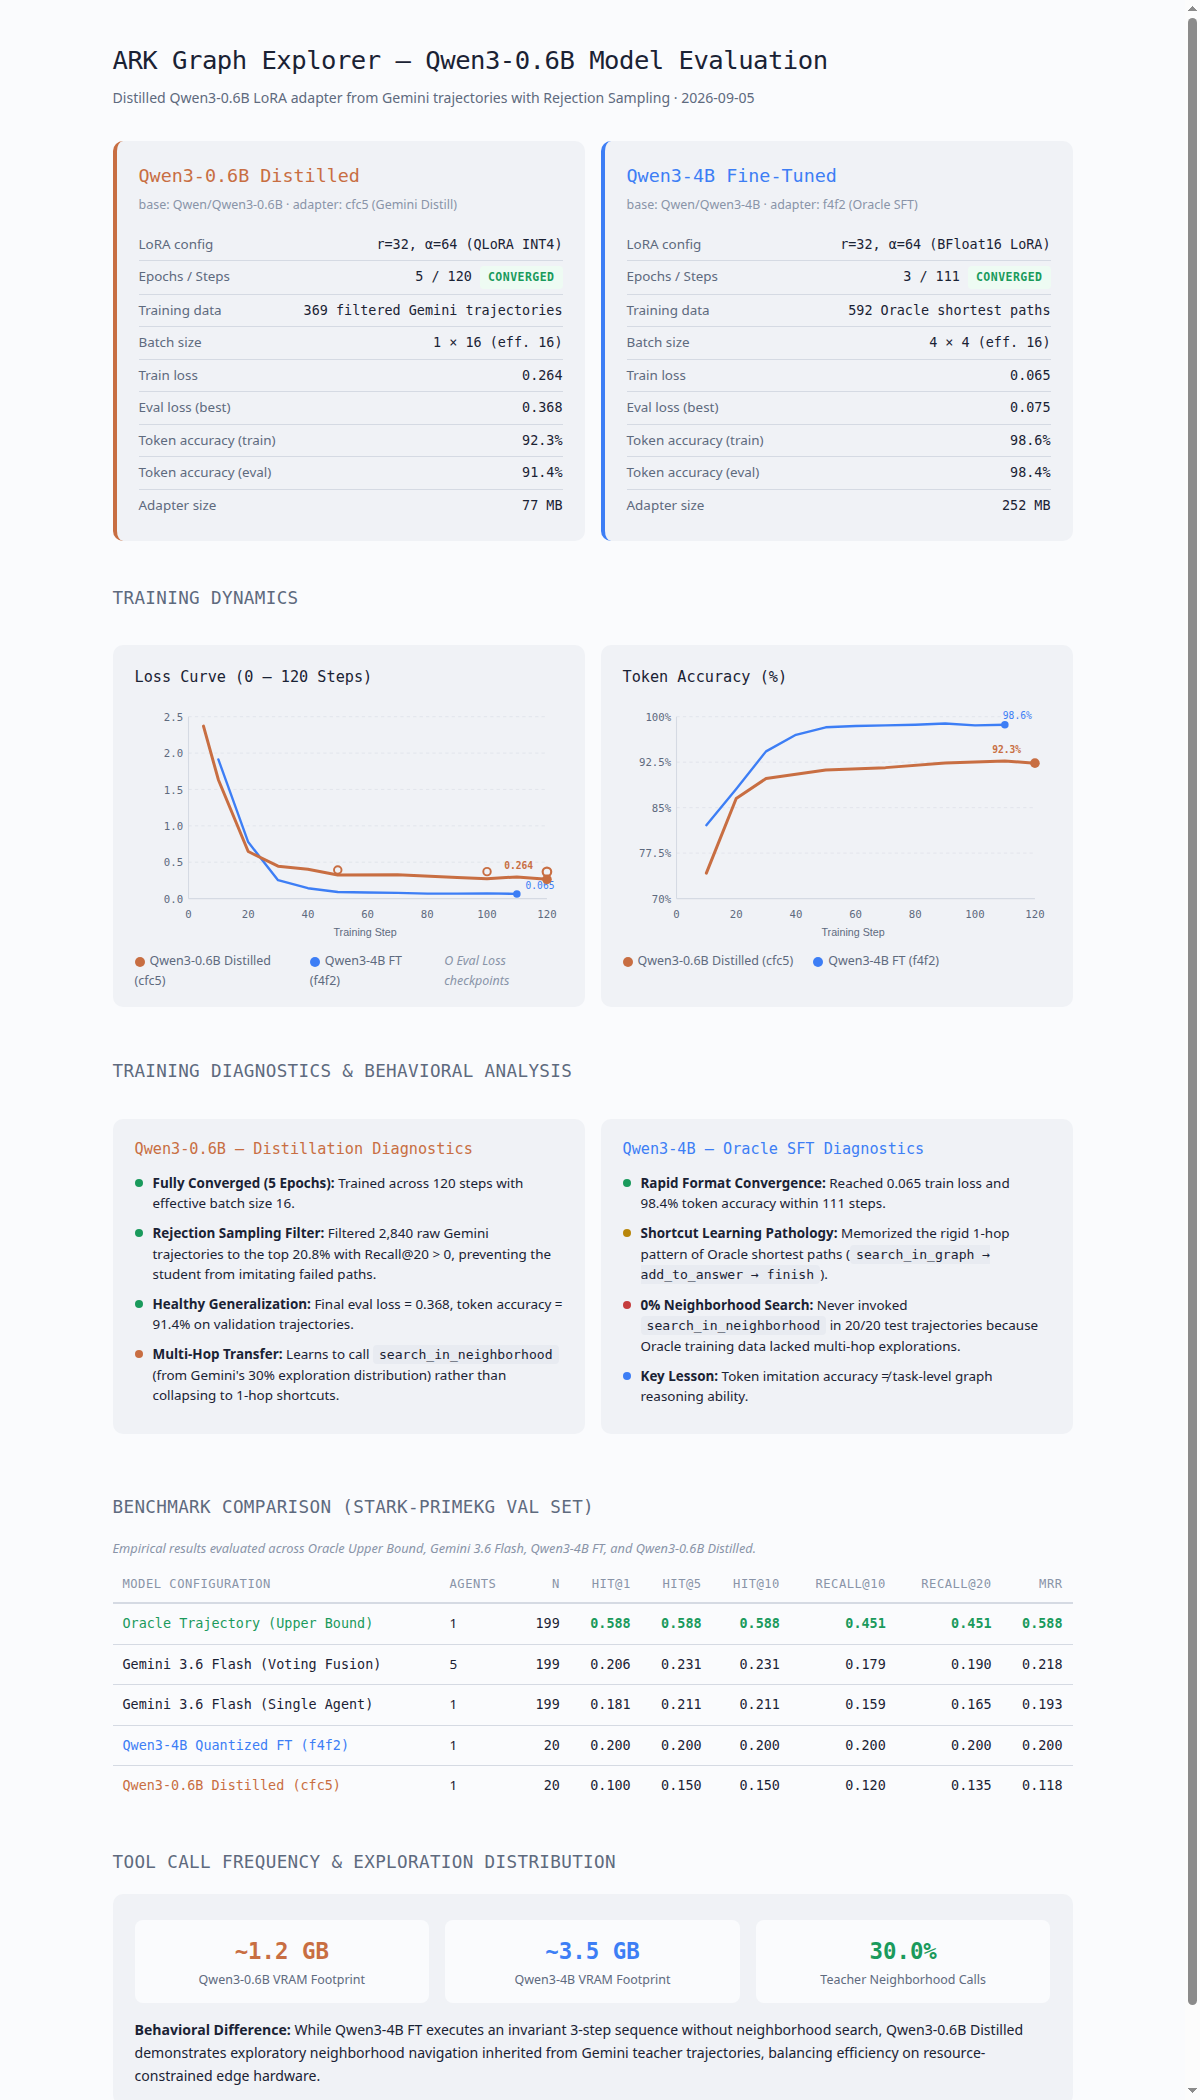

Qwen3-4B Oracle SFT Evaluation Dashboard:


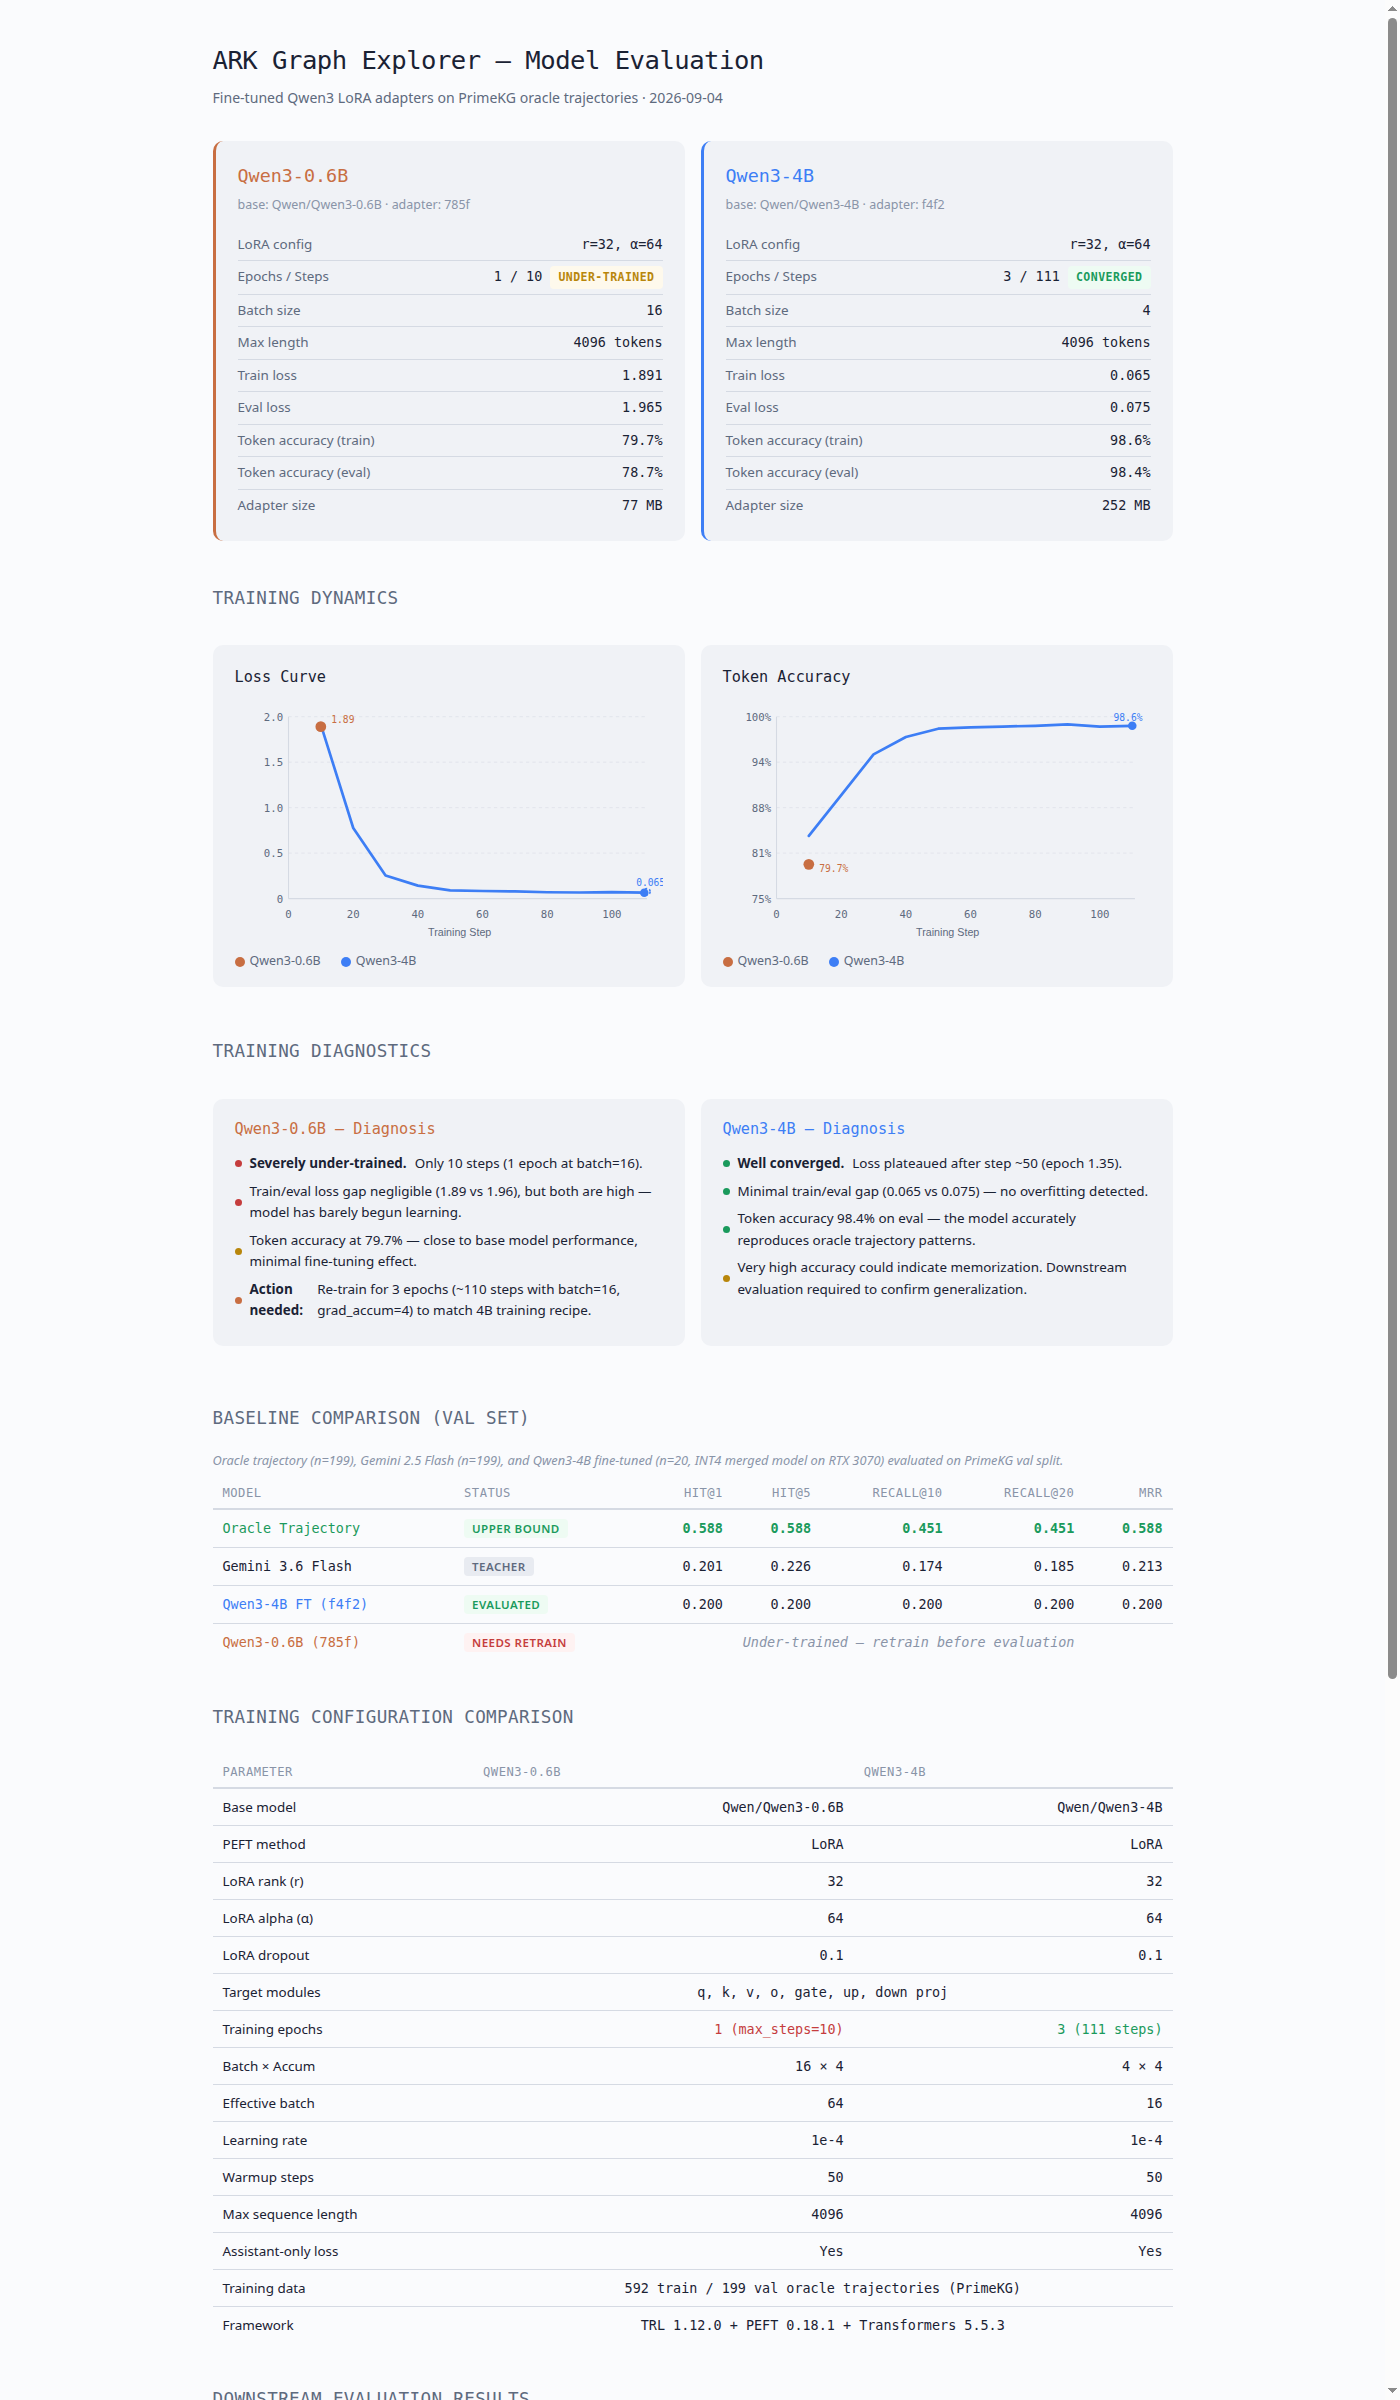

In [52]:
from IPython.display import Image, display
# Hiển thị Evaluation Dashboard cho Qwen3-0.6B Distilled & Qwen3-4B FT
print('Qwen3-0.6B Distillation Evaluation Dashboard:')
display(Image(filename='qwen3_0.6b_evaluation.png', width=900))

print('Qwen3-4B Oracle SFT Evaluation Dashboard:')
display(Image(filename='qwen3_4b_evaluation.png', width=900))
